In [27]:
import pandas as pd 

data_folder = './data/'

df1 = pd.read_csv(data_folder + 'ontario_electricity_demand.csv')
print(df1.head())
print(df1.shape)
print(df1.dtypes)

         date  hour  hourly_demand  hourly_average_price
0  2002-05-01     1       14137000                 22.97
1  2002-05-01     2       13872000                 23.27
2  2002-05-01     3       13820000                 24.54
3  2002-05-01     4       13744000                 15.17
4  2002-05-01     5       14224000                 23.59
(183432, 4)
date                     object
hour                      int64
hourly_demand             int64
hourly_average_price    float64
dtype: object


In [28]:
df1['date'] = pd.to_datetime(df1['date'])
df1['Year'] = df1['date'].dt.to_period('Y')
print(df1.head())

        date  hour  hourly_demand  hourly_average_price  Year
0 2002-05-01     1       14137000                 22.97  2002
1 2002-05-01     2       13872000                 23.27  2002
2 2002-05-01     3       13820000                 24.54  2002
3 2002-05-01     4       13744000                 15.17  2002
4 2002-05-01     5       14224000                 23.59  2002


In [29]:
yearly_demand = df1[(df1['Year'] != '2023') & (df1['Year'] != '2002')].groupby('Year').agg({
    'hourly_demand': ['mean', 'sum', 'max', 'min', 'std']
}).reset_index()

print(yearly_demand.head())

   Year hourly_demand                                                
                 mean           sum       max       min           std
0  2003  1.731957e+07  151719470000  24753000   2270000  2.617473e+06
1  2004  1.746778e+07  153436970000  24979000  11983000  2.528459e+06
2  2005  1.791913e+07  156971620000  26160000  11950000  2.744778e+06
3  2006  1.724364e+07  151054281000  27005000  11621000  2.557415e+06
4  2007  1.737507e+07  152205637000  25737000  11699000  2.637340e+06


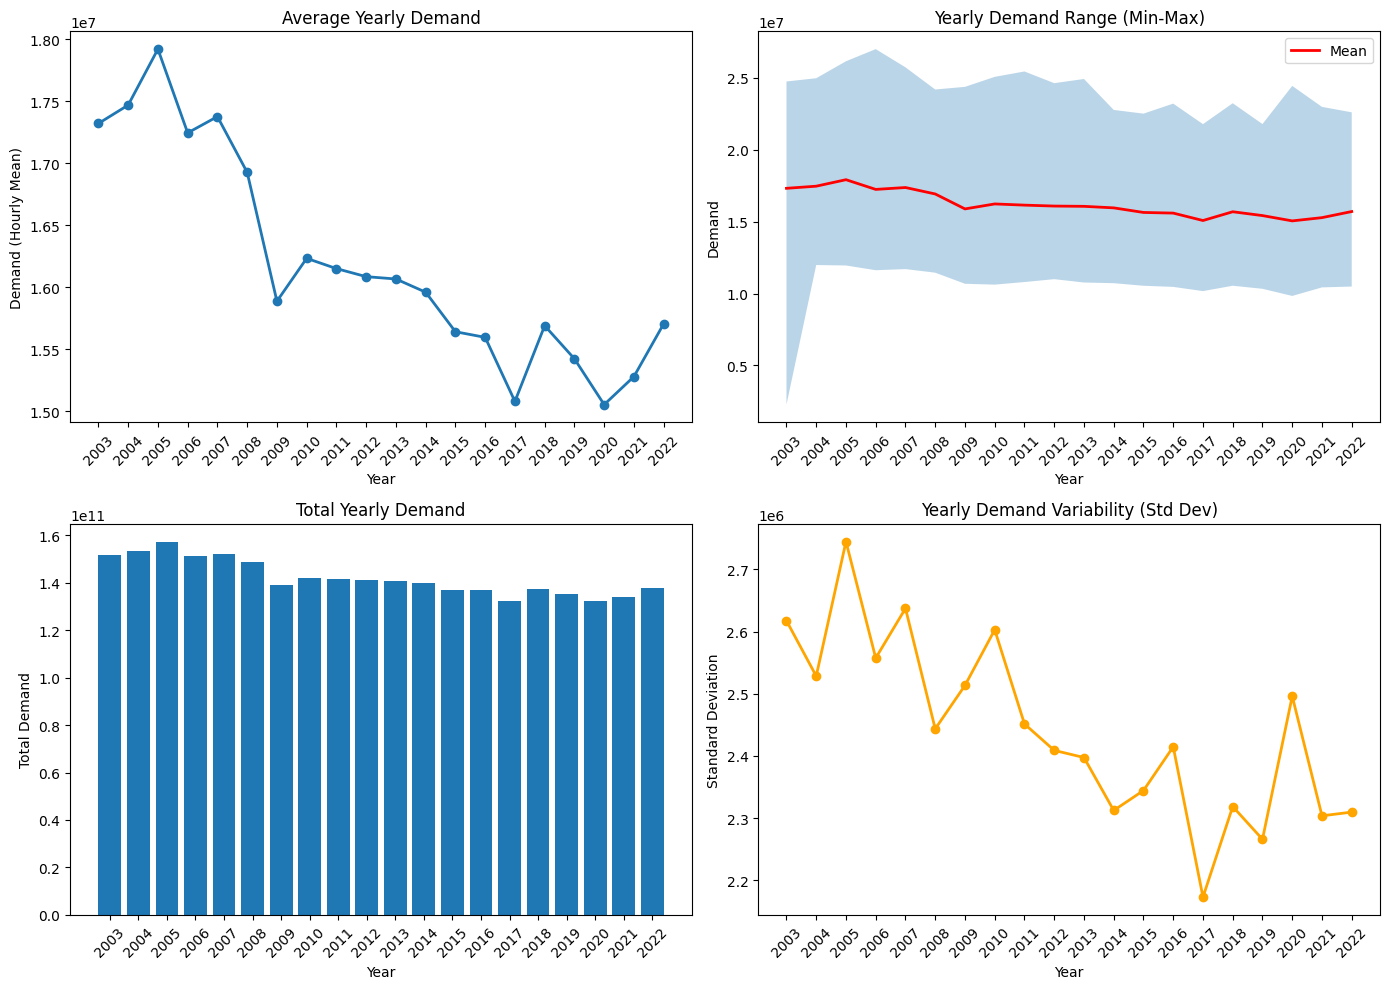

In [30]:
import matplotlib.pyplot as plt

# Flatten column names
yearly_demand.columns = ['Year', 'Mean', 'Sum', 'Max', 'Min', 'StdDev']
yearly_demand['Year'] = yearly_demand['Year'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = range(len(yearly_demand))

# Plot 1: Mean
axes[0, 0].plot(x, yearly_demand['Mean'], marker='o', linewidth=2)
axes[0, 0].set_title('Average Yearly Demand')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Demand (Hourly Mean)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(yearly_demand['Year'], rotation=45)

# Plot 2: Range
axes[0, 1].fill_between(x, yearly_demand['Min'], yearly_demand['Max'], alpha=0.3)
axes[0, 1].plot(x, yearly_demand['Mean'], color='red', label='Mean', linewidth=2)
axes[0, 1].set_title('Yearly Demand Range (Min-Max)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Demand')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(yearly_demand['Year'], rotation=45)
axes[0, 1].legend()

# Plot 3: Total
axes[1, 0].bar(x, yearly_demand['Sum'])
axes[1, 0].set_title('Total Yearly Demand')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Total Demand')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(yearly_demand['Year'], rotation=45)

# Plot 4: Std Dev
axes[1, 1].plot(x, yearly_demand['StdDev'], marker='o', color='orange', linewidth=2)
axes[1, 1].set_title('Yearly Demand Variability (Std Dev)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Standard Deviation')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(yearly_demand['Year'], rotation=45)

plt.tight_layout()
plt.show()

In [31]:
# Load HourlyDemands data
df2 = pd.read_csv(data_folder + 'HourlyDemands_1994-2002.csv')
print(df2.head())
print(df2.shape)
print(df2.dtypes)

             DateTime  OntarioDemand
0  Jan 1 1994 12:00AM          14422
1  Jan 1 1994  1:00AM          13845
2  Jan 1 1994  2:00AM          13372
3  Jan 1 1994  3:00AM          13025
4  Jan 1 1994  4:00AM          12869
(72264, 2)
DateTime         object
OntarioDemand     int64
dtype: object


In [32]:
# Process HourlyDemands data - convert date and extract year
# First, identify date column
print(df2.columns)
# Assuming there's a date column, convert and create Year column
df2_processed = df2.copy()
# Find the date column (adjust column name based on actual data)
date_col = [col for col in df2_processed.columns if 'date' in col.lower()][0]
df2_processed[date_col] = pd.to_datetime(df2_processed[date_col])
df2_processed['Year'] = df2_processed[date_col].dt.to_period('Y')
print(df2_processed.head())

Index(['DateTime', 'OntarioDemand'], dtype='object')


C:\Users\arsen\AppData\Local\Temp\ipykernel_3352\1381014510.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2_processed[date_col] = pd.to_datetime(df2_processed[date_col])


             DateTime  OntarioDemand  Year
0 1994-01-01 00:00:00          14422  1994
1 1994-01-01 01:00:00          13845  1994
2 1994-01-01 02:00:00          13372  1994
3 1994-01-01 03:00:00          13025  1994
4 1994-01-01 04:00:00          12869  1994


In [33]:
# Aggregate HourlyDemands by year (excluding 2002)
# Find the demand column
demand_col = [col for col in df2_processed.columns if 'demand' in col.lower()][0]

hourly_yearly_demand = df2_processed[df2_processed['Year'] != '2002'].groupby('Year').agg({
    demand_col: ['mean', 'sum', 'max', 'min', 'std']
}).reset_index()

print(hourly_yearly_demand.head())

   Year OntarioDemand                                      
                 mean        sum    max    min          std
0  1994  15550.044292  136218388  23856   9952  2603.420386
1  1995  15810.212557  138497462  22812  10207  2472.264542
2  1996  15797.793033  138767814  22072  10234  2377.090657
3  1997  15981.698402  139999678  22030  10515  2296.151979
4  1998  16174.941895  141692491  22403  11125  2278.246170


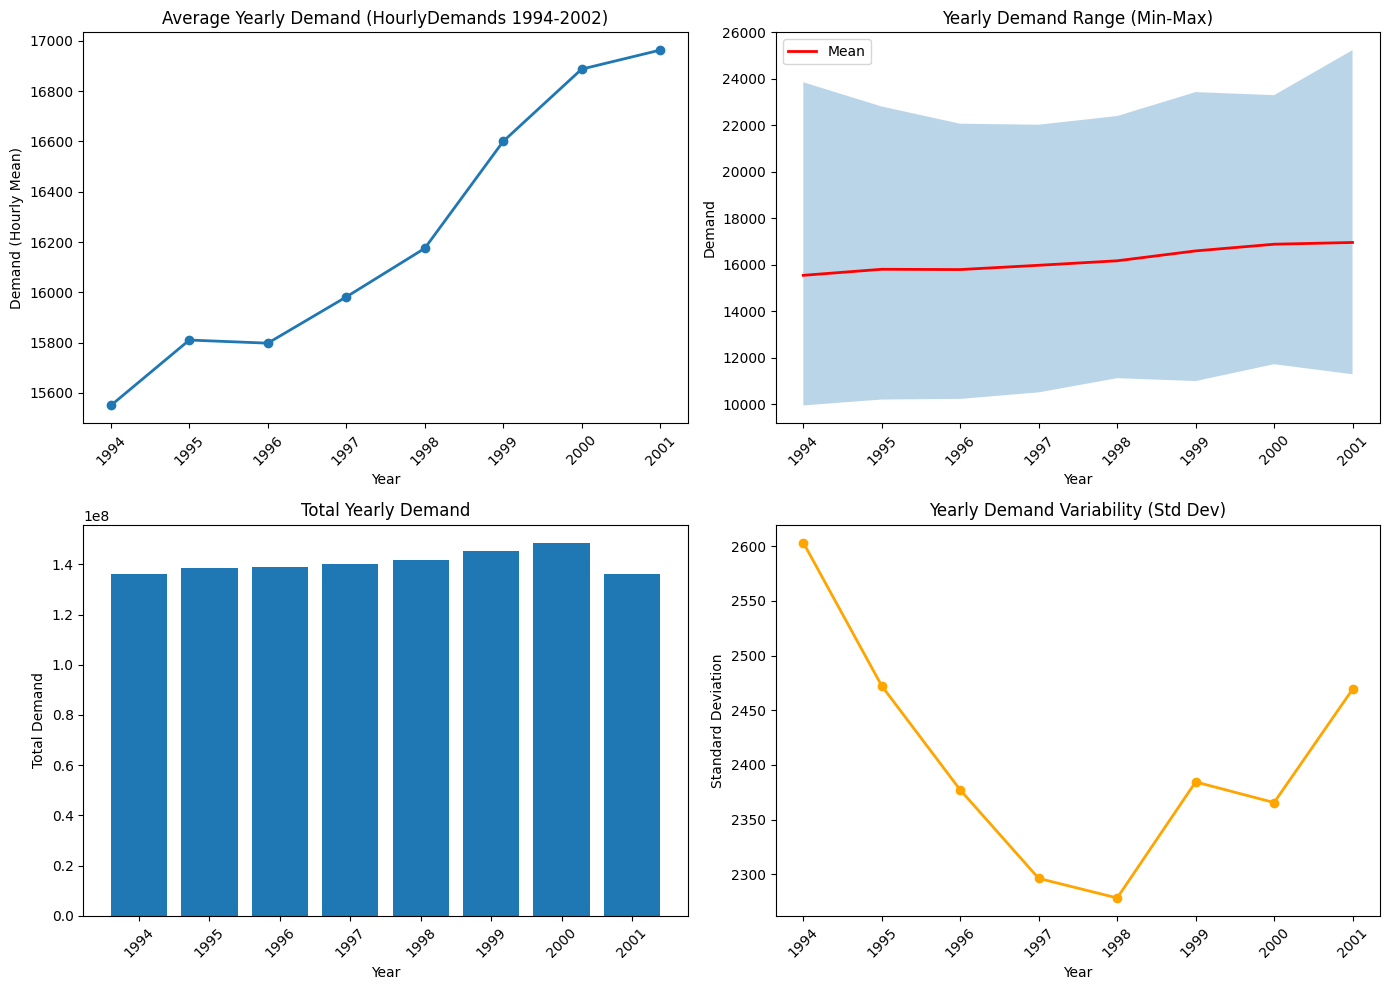

In [34]:
# Graph HourlyDemands yearly data
# Flatten column names
hourly_yearly_demand.columns = ['Year', 'Mean', 'Sum', 'Max', 'Min', 'StdDev']
hourly_yearly_demand['Year'] = hourly_yearly_demand['Year'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = range(len(hourly_yearly_demand))

# Plot 1: Mean
axes[0, 0].plot(x, hourly_yearly_demand['Mean'], marker='o', linewidth=2)
axes[0, 0].set_title('Average Yearly Demand (HourlyDemands 1994-2002)')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Demand (Hourly Mean)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(hourly_yearly_demand['Year'], rotation=45)

# Plot 2: Range
axes[0, 1].fill_between(x, hourly_yearly_demand['Min'], hourly_yearly_demand['Max'], alpha=0.3)
axes[0, 1].plot(x, hourly_yearly_demand['Mean'], color='red', label='Mean', linewidth=2)
axes[0, 1].set_title('Yearly Demand Range (Min-Max)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Demand')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(hourly_yearly_demand['Year'], rotation=45)
axes[0, 1].legend()

# Plot 3: Total
axes[1, 0].bar(x, hourly_yearly_demand['Sum'])
axes[1, 0].set_title('Total Yearly Demand')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Total Demand')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(hourly_yearly_demand['Year'], rotation=45)

# Plot 4: Std Dev
axes[1, 1].plot(x, hourly_yearly_demand['StdDev'], marker='o', color='orange', linewidth=2)
axes[1, 1].set_title('Yearly Demand Variability (Std Dev)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Standard Deviation')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(hourly_yearly_demand['Year'], rotation=45)

plt.tight_layout()
plt.show()

In [42]:
# Combine both datasets with GLOBAL NORMALIZATION
# Prepare df1 and df2 raw data
df1_raw = df1.copy()
df1_raw['date'] = pd.to_datetime(df1_raw['date'])
df1_raw['Year'] = df1_raw['date'].dt.to_period('Y')
df1_raw = df1_raw[['date', 'Year', 'hourly_demand']].copy()

df2_raw = df2_processed[[date_col, 'Year', demand_col]].copy()
df2_raw.columns = ['date', 'Year', 'hourly_demand']

# Combine BEFORE normalization
combined_raw = pd.concat([df1_raw, df2_raw], ignore_index=True)

# Normalize both to 0-1 using GLOBAL min/max
global_min = combined_raw['hourly_demand'].min()
global_max = combined_raw['hourly_demand'].max()
combined_df = combined_raw.copy()
combined_df['hourly_demand'] = (combined_df['hourly_demand'] - global_min) / (global_max - global_min)

print(f"Combined dataset shape: {combined_df.shape}")
print(f"Date range: {combined_df['date'].min()} to {combined_df['date'].max()}")
print(f"\nGlobal Normalization applied:")
print(f"Global range: {global_min:.2e} to {global_max:.2e}")
print(f"Both datasets normalized to 0-1 using same scale")
print(combined_df.head())

Combined dataset shape: (255696, 3)
Date range: 1994-01-01 00:00:00 to 2023-04-03 00:00:00

Global Normalization applied:
Global range: 9.95e+03 to 2.70e+07
Both datasets normalized to 0-1 using same scale
        date  Year  hourly_demand
0 2002-05-01  2002       0.523320
1 2002-05-01  2002       0.513503
2 2002-05-01  2002       0.511577
3 2002-05-01  2002       0.508762
4 2002-05-01  2002       0.526543


In [47]:
# Debug: Check the normalized values and transitions
print("=== GLOBAL NORMALIZED DATA ANALYSIS ===")
print(f"\ndf1_raw (before normalization) stats:")
print(df1_raw['hourly_demand'].describe())

print(f"\ndf2_raw (before normalization) stats:")
print(df2_raw['hourly_demand'].describe())

print(f"\nCombined after global normalization stats:")
print(combined_df['hourly_demand'].describe())

print(f"\nMean by Year (globally normalized):")
mean_by_year = combined_df.groupby('Year')['hourly_demand'].mean()
print(mean_by_year)

print(f"\nYear-to-year change:")
for i in range(1, len(mean_by_year)):
    current_year = mean_by_year.index[i]
    prev_year = mean_by_year.index[i-1]
    change = mean_by_year.iloc[i] - mean_by_year.iloc[i-1]
    pct_change = (change / mean_by_year.iloc[i-1]) * 100 if mean_by_year.iloc[i-1] != 0 else 0
    print(f"{prev_year} → {current_year}: {change:.4f} ({pct_change:+.1f}%)")

=== GLOBAL NORMALIZED DATA ANALYSIS ===

df1_raw (before normalization) stats:
count    1.834320e+05
mean     1.624913e+07
std      2.592200e+06
min      2.270000e+06
25%      1.430700e+07
50%      1.614600e+07
75%      1.803900e+07
max      2.700500e+07
Name: hourly_demand, dtype: float64

df2_raw (before normalization) stats:
count    72264.000000
mean     16263.594570
std       2456.487434
min       9952.000000
25%      14417.000000
50%      16372.500000
75%      18029.000000
max      25239.000000
Name: hourly_demand, dtype: float64

Combined after global normalization stats:
count    255696.000000
mean          0.431616
std           0.282713
min           0.000000
25%           0.000345
50%           0.544768
75%           0.638934
max           1.000000
Name: hourly_demand, dtype: float64

Mean by Year (globally normalized):
Year
1994    0.000207
1995    0.000217
1996    0.000217
1997    0.000223
1998    0.000231
1999    0.000246
2000    0.000257
2001    0.000260
2002    0.435291

In [48]:
# Aggregate combined data by year (exclude 2002 and 2023)
combined_yearly = combined_df[(combined_df['Year'] != '2002') & (combined_df['Year'] != '2023')].groupby('Year').agg({
    'hourly_demand': ['mean', 'sum', 'max', 'min', 'std']
}).reset_index()

print(combined_yearly.head())

   Year hourly_demand                                        
                 mean       sum       max       min       std
0  1994      0.000207  1.816588  0.000515  0.000000  0.000096
1  1995      0.000217  1.901013  0.000476  0.000009  0.000092
2  1996      0.000217  1.902180  0.000449  0.000010  0.000088
3  1997      0.000223  1.956661  0.000447  0.000021  0.000085
4  1998      0.000231  2.019369  0.000461  0.000043  0.000084


In [ ]:
# Clean up: Remove old/broken debug cell
print("Global normalization complete. Ready for graphing.")

=== DEBUG COMBINED DATA ===

df1_combined stats:
count    183432.000000
mean          0.565156
std           0.104799
min           0.000000
25%           0.486638
50%           0.560986
75%           0.637518
max           1.000000
Name: hourly_demand, dtype: float64

df2_combined stats (before concat):
count    72264.000000
mean         0.412873
std          0.160691
min          0.000000
25%          0.292078
50%          0.419997
75%          0.528357
max          1.000000
Name: hourly_demand, dtype: float64
df2_combined dtypes: date             datetime64[ns]
Year              period[Y-DEC]
hourly_demand           float64
dtype: object
df2_combined head:
                 date  Year  hourly_demand
0 1994-01-01 00:00:00  1994       0.292405
1 1994-01-01 01:00:00  1994       0.254661
2 1994-01-01 02:00:00  1994       0.223720
3 1994-01-01 03:00:00  1994       0.201020
4 1994-01-01 04:00:00  1994       0.190816

Combined_df rows by year:
Year
1994    8760
1995    8760
1996    8784
199

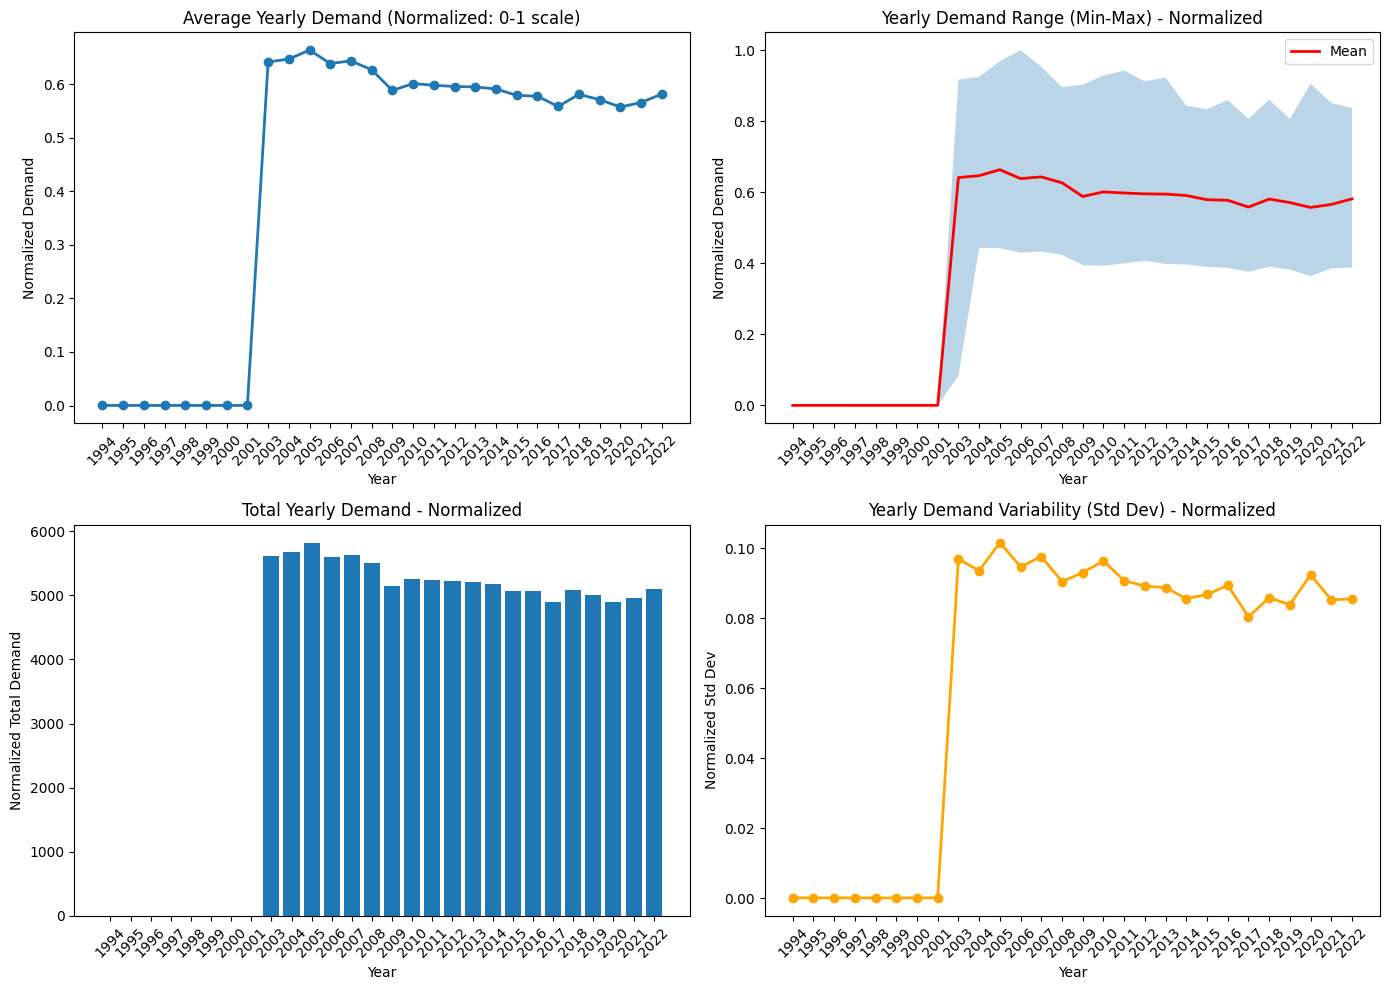

In [50]:
# Graph combined normalized data
# Flatten column names
combined_yearly.columns = ['Year', 'Mean', 'Sum', 'Max', 'Min', 'StdDev']
combined_yearly['Year'] = combined_yearly['Year'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = range(len(combined_yearly))

# Plot 1: Mean
axes[0, 0].plot(x, combined_yearly['Mean'], marker='o', linewidth=2)
axes[0, 0].set_title('Average Yearly Demand (Normalized: 0-1 scale)')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Normalized Demand')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(combined_yearly['Year'], rotation=45)

# Plot 2: Range
axes[0, 1].fill_between(x, combined_yearly['Min'], combined_yearly['Max'], alpha=0.3)
axes[0, 1].plot(x, combined_yearly['Mean'], color='red', label='Mean', linewidth=2)
axes[0, 1].set_title('Yearly Demand Range (Min-Max) - Normalized')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Normalized Demand')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(combined_yearly['Year'], rotation=45)
axes[0, 1].legend()

# Plot 3: Total
axes[1, 0].bar(x, combined_yearly['Sum'])
axes[1, 0].set_title('Total Yearly Demand - Normalized')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Normalized Total Demand')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(combined_yearly['Year'], rotation=45)

# Plot 4: Std Dev
axes[1, 1].plot(x, combined_yearly['StdDev'], marker='o', color='orange', linewidth=2)
axes[1, 1].set_title('Yearly Demand Variability (Std Dev) - Normalized')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Normalized Std Dev')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(combined_yearly['Year'], rotation=45)

plt.tight_layout()
plt.show()